In [2]:
from google.colab import files

uploaded = files.upload()

Saving Food_Waste_Prediction_Dataset (1).xlsx to Food_Waste_Prediction_Dataset (1).xlsx


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/content/Food_Waste_Prediction_Dataset (1).xlsx")



In [4]:
print(df.head())
print(df.shape)
print(df.dtypes)

  Restaurant_ID Restaurant_Name        City       Cuisine Food_Item  \
0          R001    Spice Garden     Chennai  South Indian    Pongal   
1          R005      Green Bowl      Mumbai  South Indian      Dosa   
2          R002     Urban Bites   Bengaluru       Italian     Pasta   
3          R004        Food Hub  Coimbatore  South Indian     Meals   
4          R003     Ocean Treat   Hyderabad  South Indian      Dosa   

         Date  Prepared_Quantity  Sold_Quantity  Remaining_Quantity  \
0  2025-05-06                107            102                   5   
1  2025-11-29                229            198                  31   
2  2025-05-23                 89             89                   0   
3  2025-02-10                191            175                  16   
4  2025-02-21                147            113                  34   

   Temperature_C Weather Weekend Holiday  Discount_Percent  Customers  \
0             25  Cloudy      No      No                20        121   


In [5]:
print(df.describe())


       Prepared_Quantity  Sold_Quantity  Remaining_Quantity  Temperature_C  \
count        1000.000000    1000.000000         1000.000000    1000.000000   
mean          174.901000     139.040000           35.861000      31.218000   
std            72.412933      61.215797           24.186622       5.480375   
min            50.000000      18.000000            0.000000      22.000000   
25%           111.000000      86.000000           17.000000      26.000000   
50%           177.000000     139.000000           33.000000      32.000000   
75%           239.000000     189.000000           53.000000      36.000000   
max           300.000000     294.000000          112.000000      40.000000   

       Discount_Percent    Customers  Waste_Amount_kg  
count       1000.000000  1000.000000      1000.000000  
mean          13.060000    98.848000         9.495850  
std            8.634869    55.011591         6.696288  
min            0.000000    11.000000         0.000000  
25%            5.

In [6]:
high_waste = df[df["Waste_Amount_kg"] > 10]

print(high_waste.head())

   Restaurant_ID Restaurant_Name        City       Cuisine  \
8           R003     Ocean Treat   Hyderabad  North Indian   
9           R004        Food Hub  Coimbatore       Italian   
10          R003     Ocean Treat   Hyderabad  South Indian   
11          R005      Green Bowl      Mumbai  North Indian   
13          R004        Food Hub  Coimbatore  North Indian   

               Food_Item        Date  Prepared_Quantity  Sold_Quantity  \
8   Paneer Butter Masala  2025-09-18                176             99   
9                  Pasta  2025-10-11                270            226   
10                Pongal  2025-08-11                 90             53   
11  Paneer Butter Masala  2025-07-11                245            183   
13                  Naan  2025-09-28                273            188   

    Remaining_Quantity  Temperature_C Weather Weekend Holiday  \
8                   77             23   Rainy      No      No   
9                   44             25  Cloudy     Ye

In [7]:
chennai = df[df["City"] == "Chennai"]

print(chennai.head())

   Restaurant_ID Restaurant_Name     City       Cuisine             Food_Item  \
0           R001    Spice Garden  Chennai  South Indian                Pongal   
15          R001    Spice Garden  Chennai  North Indian  Paneer Butter Masala   
17          R001    Spice Garden  Chennai  South Indian                 Meals   
22          R001    Spice Garden  Chennai  North Indian  Paneer Butter Masala   
30          R001    Spice Garden  Chennai       Chinese            Fried Rice   

          Date  Prepared_Quantity  Sold_Quantity  Remaining_Quantity  \
0   2025-05-06                107            102                   5   
15  2025-01-17                270            218                  52   
17  2025-06-23                254            223                  31   
22  2025-11-01                 67             61                   6   
30  2025-12-16                113            109                   4   

    Temperature_C Weather Weekend Holiday  Discount_Percent  Customers  \
0     

In [8]:
sorted_df = df.sort_values(
    by="Waste_Amount_kg",
    ascending=False
)

print(sorted_df.head())

    Restaurant_ID Restaurant_Name        City       Cuisine   Food_Item  \
693          R003     Ocean Treat   Hyderabad       Italian       Pasta   
696          R001    Spice Garden     Chennai       Italian       Pizza   
278          R005      Green Bowl      Mumbai       Chinese  Manchurian   
816          R001    Spice Garden     Chennai       Italian       Pasta   
316          R004        Food Hub  Coimbatore  South Indian       Meals   

           Date  Prepared_Quantity  Sold_Quantity  Remaining_Quantity  \
693  2025-02-12                266            168                  98   
696  2025-03-13                235            128                 107   
278  2025-04-30                299            198                 101   
816  2025-05-06                239            148                  91   
316  2025-01-28                271            171                 100   

     Temperature_C Weather Weekend Holiday  Discount_Percent  Customers  \
693             28   Rainy      No 

In [9]:
print("Mean :", df["Waste_Amount_kg"].mean())
print("Median :", df["Waste_Amount_kg"].median())
print("Mode :")
print(df["Waste_Amount_kg"].mode())
print("Standard Deviation :", df["Waste_Amount_kg"].std())

Mean : 9.495849999999999
Median : 8.375
Mode :
0    0.0
Name: Waste_Amount_kg, dtype: float64
Standard Deviation : 6.696287833437881


In [10]:
city_avg = (
    df.groupby("City")["Waste_Amount_kg"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(city_avg)

City
Hyderabad     10.080890
Chennai        9.755308
Coimbatore     9.438700
Mumbai         9.332198
Bengaluru      8.915880
Name: Waste_Amount_kg, dtype: float64


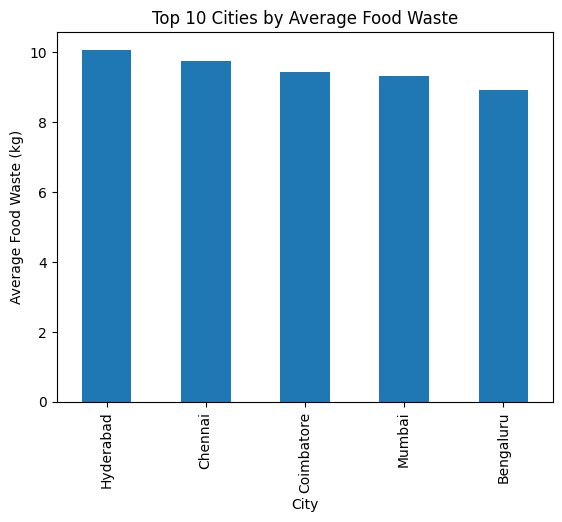

In [11]:
city_avg.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Cities by Average Food Waste")
plt.ylabel("Average Food Waste (kg)")
plt.xlabel("City")

plt.show()

In [12]:
corr = df[
    [
        "Prepared_Quantity",
        "Sold_Quantity",
        "Remaining_Quantity",
        "Temperature_C",
        "Discount_Percent",
        "Customers",
        "Waste_Amount_kg"
    ]
].corr()

print(corr)

                    Prepared_Quantity  Sold_Quantity  Remaining_Quantity  \
Prepared_Quantity            1.000000       0.948157            0.594160   
Sold_Quantity                0.948157       1.000000            0.307735   
Remaining_Quantity           0.594160       0.307735            1.000000   
Temperature_C               -0.024493      -0.012999           -0.040430   
Discount_Percent            -0.018582       0.098393           -0.304663   
Customers                    0.769898       0.805486            0.266351   
Waste_Amount_kg              0.564823       0.292245            0.951373   

                    Temperature_C  Discount_Percent  Customers  \
Prepared_Quantity       -0.024493         -0.018582   0.769898   
Sold_Quantity           -0.012999          0.098393   0.805486   
Remaining_Quantity      -0.040430         -0.304663   0.266351   
Temperature_C            1.000000          0.016455  -0.029530   
Discount_Percent         0.016455          1.000000   0.05913

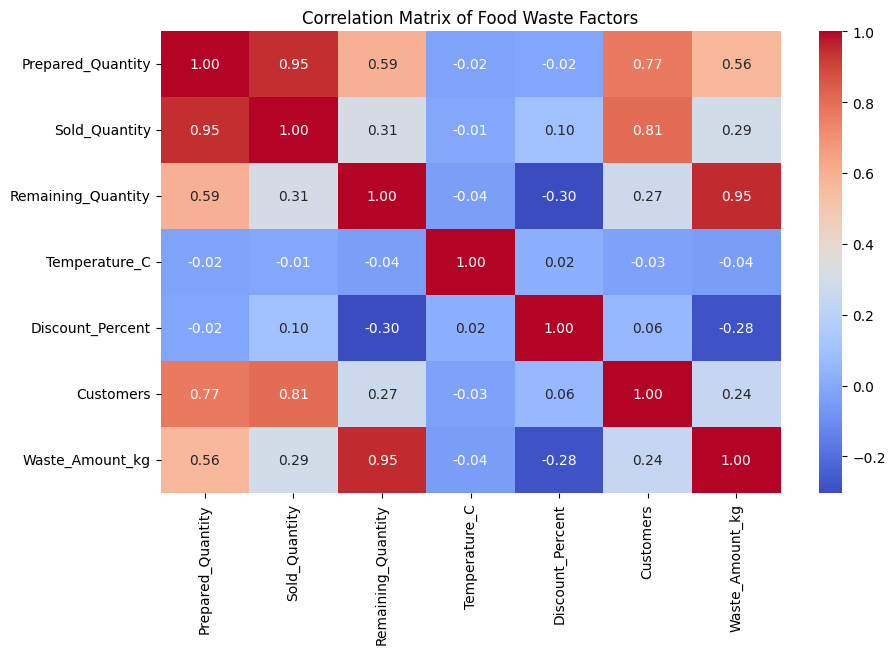

In [13]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Food Waste Factors")
plt.show()

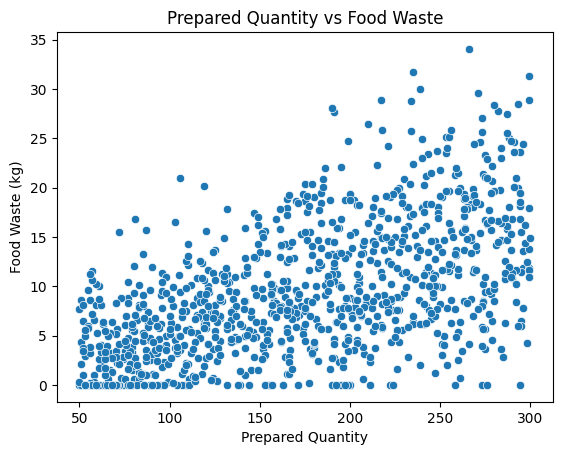

In [14]:
sns.scatterplot(
    data=df,
    x="Prepared_Quantity",
    y="Waste_Amount_kg"
)

plt.title("Prepared Quantity vs Food Waste")
plt.xlabel("Prepared Quantity")
plt.ylabel("Food Waste (kg)")

plt.show()